### SVMs y optimización de hiperparámetros

En este notebook trabajaremos con un dataset simulado de eventos del experimento ATLAS. Cada fila representa un evento de colisión protón–protón, y cada columna corresponde a una variable reconstruida a partir de los objetos físicos detectados en el evento: jets, leptones, energía faltante, etc.

El objetivo es distinguir entre dos tipos de eventos:

- **`ttbar`**: producción de un par top–antitop. Es un proceso mucho más frecuente.
- **`4top`**: producción de cuatro quarks top. Es un proceso mucho más raro y corresponde a nuestra clase positiva.


Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)





In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.svm import SVC, LinearSVC # Nuevo algoritmo!
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, cross_validate
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn import metrics
from sklearn.model_selection import GridSearchCV # Nuevo! Para explorar los hiperparámetros del modelo

In [2]:
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_colwidth', 100)
rc('text', usetex=False)

Leemos las características y las etiquetas  

In [3]:
features = pd.read_csv('ParticleID_features.csv', index_col='ID')

In [4]:
features.head(10)

,MET,METphi,Type_1,P1,P2,P3,P4,Type_2,P5,P6,P7,P8,Type_3,P9,P10,P11,P12,Type_4,P13,P14,P15,P16,Type_5,P17,P18,P19,P20,Type_6,P21,P22,P23,P24,Type_7,P25,P26,P27,P28,Type_8,P29,P30,P31,P32,Type_9,P33,P34,P35,P36,Type_10,P37,P38,P39,P40,Type_11,P41,P42,P43,P44,Type_12,P45,P46,P47,P48,Type_13,P49,P50,P51,P52
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,62803.50,-1.810010,j,137571.0,128444.0,-0.345744,-0.307112,j,174209.0,127932.0,0.826569,2.332000,b,86788.9,84554.9,-0.180795,2.187970,j,140289.0,76955.8,-1.199330,-1.302800,m+,85230.6,70102.4,-0.645689,-1.659540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,57594.20,-0.509253,j,161529.0,80458.3,-1.318010,1.402050,j,291490.0,68462.9,-2.126740,-2.582310,e-,44270.1,35139.6,-0.706120,-0.371392,e+,72883.9,26902.2,-1.653860,-3.129630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,82313.30,1.686840,b,167130.0,113078.0,0.937258,-2.068680,j,102423.0,54922.3,1.226850,0.646589,j,60768.9,36244.3,1.102890,-1.434480,j,77714.0,27801.5,1.684610,1.389690,j,26840.0,24469.3,-0.388937,-1.647260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,30610.80,2.617120,j,112267.0,61383.9,-1.211050,-1.457800,b,40647.8,39472.0,-0.024646,-2.222800,j,201589.0,32978.6,-2.496040,1.137810,j,90096.7,26964.5,1.871320,0.817631,j,28235.4,25887.9,-0.411528,2.024290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,45153.10,-2.241350,j,178174.0,100164.0,1.166880,-0.018721,j,92351.3,69762.1,0.774114,2.568740,j,61625.2,50086.7,0.652572,-3.012800,j,104193.0,31151.0,1.876410,0.865381,j,746585.0,26219.3,4.041820,-0.874169,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,43803.10,0.572184,b,146274.0,111016.0,-0.776311,1.083980,j,1036150.0,109475.0,-2.937790,-1.518380,j,259026.0,71613.8,-1.955480,-1.726540,j,137198.0,59925.9,-1.469500,2.189410,j,95419.6,55847.5,1.123310,0.846395,j,451389.0,53178.9,-2.827840,-2.47964,j,51436.4,50713.2,0.056029,2.258540,j,152293.0,48842.5,-1.80056,-0.704609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,28100.40,-0.593429,j,458244.0,391557.0,-0.546723,0.013275,b,425427.0,328566.0,-0.728581,-2.411570,j,126694.0,116820.0,-0.350992,2.208790,j,112382.0,111318.0,0.073453,3.030960,j,3039490.0,65143.9,4.535880,1.516880,j,86235.2,65037.1,0.780704,1.50869,b,62675.6,61535.7,0.099510,0.466516,j,82070.6,45537.5,-1.18149,-3.047850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,166458.00,0.473635,j,848058.0,273398.0,-1.794510,2.763560,j,267149.0,242308.0,-0.425923,-1.534860,b,461064.0,159944.0,-1.719880,1.094360,j,75909.0,73858.8,-0.235076,-0.330519,b,201351.0,53338.2,-2.002180,-2.376840,b,38794.0,37225.5,0.187429,-2.78635,b,40323.4,36915.1,0.411490,1.844490,j,195049.0,28645.2,-2.60528,-1.434260,j,210687.0,26560.5,2.75992,0.315873,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,4664.13,-1.828120,j,477219.0,331550.0,-0.899484,0.698675,b,696365.0,246682.0,-1.697140,-2.285070,j,987005.0,62516.5,-3.451230,-2.207720,j,51561.9,36406.3,-0.881624,-2.923760,j,85262.1,35203.6,-1.527390,2.071480,j,202166.0,26361.8,-2.725680,-2.21350,j,56071.6,25934.6,-1.403180,1.130990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Cada fila del dataset corresponde a un evento de colisión protón-protón.
Para cada evento se conoce:
- Energía faltante:
  - `MET`: energía transversa faltante (*missing transverse energy*)
  - `METphi`: ángulo azimutal asociado a la dirección de la energía faltante
- Información de cada partícula reconstruida: Para cada partícula se registra:
    - Tipo de partícula, que puede ser: electrón, positrón, fotón, jet, b-jet, muón con carga positiva, muón con carga negativa
    - 4-vector, que describe la cinemática de la partícula. En este dataset, el 4-vector incluye: energía, momento transversal, pseudorapidez $\eta$ y ángulo azimutal $\phi$


In [5]:
features.shape

(5000, 67)

In [6]:
y = np.genfromtxt('ParticleID_labels.txt', dtype = str)

In [7]:
y

array(['ttbar', 'ttbar', 'ttbar', ..., 'ttbar', '4top', 'ttbar'],
      dtype='<U5')

### Objetivo del problema

Queremos entrenar un clasificador que distinga entre dos tipos de eventos:

- `ttbar`: producción de un par top-antitop.
- `4top`: producción de cuatro quarks top.

#### Necesitamos transformar las dos categorías de targets desde un string a un valor numérico, como 0/1. Podemos usar la función [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) de sklearn

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder() #cambia las categorías a 1...N

In [9]:
y

array(['ttbar', 'ttbar', 'ttbar', ..., 'ttbar', '4top', 'ttbar'],
      dtype='<U5')

In [10]:
y = le.fit_transform(y)

In [11]:
le.classes_

array(['4top', 'ttbar'], dtype='<U5')

`LabelEncoder` asigna números a las clases en el orden definido por `le.classes_`.  
Como queremos que `4top` sea la clase positiva, revisamos la codificación y, si es necesario, invertimos las etiquetas.

In [12]:
target = np.abs(y - 1)

In [13]:
target # Ahora sí

array([0, 0, 0, ..., 0, 1, 0])

In [14]:
y.shape

(5000,)

#### Echemos un vistazo a las características

In [15]:
features.describe() #Esto excluye a las columnas con datos no-numéricos

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20,P21,P22,P23,P24,P25,P26,P27,P28,P29,P30,P31,P32,P33,P34,P35,P36,P37,P38,P39,P40,P41,P42,P43,P44,P45,P46,P47,P48,P49,P50,P51,P52
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,4.997000e+03,4.997000e+03,4997.000000,4997.000000,4.950000e+03,4950.000000,4950.000000,4950.000000,4.717000e+03,4717.000000,4717.000000,4717.000000,4.002000e+03,4002.000000,4002.000000,4002.000000,2.871000e+03,2871.00000,2871.000000,2871.000000,1.889000e+03,1889.000000,1889.000000,1889.000000,1.186000e+03,1186.000000,1186.000000,1186.000000,7.290000e+02,729.000000,729.000000,729.000000,4.420000e+02,442.000000,442.000000,442.000000,2.610000e+02,261.000000,261.000000,261.000000,1.270000e+02,127.000000,127.000000,127.000000,5.600000e+01,56.000000,56.000000,56.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.527799e+05,1.080302e+05,-0.029936,0.007327,2.117980e+05,74863.343131,-0.025104,0.011845,1.805997e+05,57289.049481,0.010723,0.045266,1.780366e+05,48798.018516,0.015167,-0.031312,1.705620e+05,44042.67015,-0.022948,0.014522,1.628825e+05,41151.069666,0.002228,0.006738,1.581409e+05,40250.387015,0.072349,-0.035907,1.596814e+05,40139.289849,0.061654,-0.045868,1.574039e+05,39703.038235,0.118543,0.024249,1.561160e+05,38173.716092,0.029455,0.026422,1.631051e+05,34876.849606,0.206978,-0.001085,1.456600e+05,36151.183929,-0.000879,0.219260
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638580e+05,8.136261e+04,1.439105,1.828832,2.510361e+05,46309.512365,1.577316,1.802715,2.383403e+05,32013.857623,1.634072,1.812078,2.577958e+05,26252.978520,1.744489,1.784248,2.381745e+05,23510.65367,1.806611,1.811101,2.269341e+05,20988.953157,1.815312,1.771888,2.118782e+05,26556.025657,1.836492,1.796932,2.308620e+05,30074.756789,1.842798,1.788596,2.165489e+05,30502.312276,1.872084,1.826435,2.319016e+05,29324.658352,1.884750,1.753017,2.248603e+05,20433.767238,1.998859,1.949004,1.943657e+05,25861.883410,1.941707,1.910400
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,1.087540e+04,1.080000e+04,-4.668790,-3.140530,1.221050e+04,10639.800000,-4.520250,-3.141480,1.169190e+04,10818.000000,-4.616550,-3.136130,1.110310e+04,10287.000000,-4.778980,-3.139040,1.070330e+04,10066.90000,-4.930230,-3.140380,1.197700e+04,11260.200000,-4.758150,-3.135630,1.380860e+04,10973.300000,-4.606330,-3.132610,1.119760e+04,10067.900000,-4.814380,-3.136380,1.615530e+04,10183.700000,-4.803880,-3.135910,2.004750e+04,14800.200000,-4.400470,-3.130690,1.780380e+04,12987.900000,-4.447660,-3.139820,2.512510e+04,14836.000000,-4.448760,-2.990730
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007510e+05,6.321840e+04,-1.060500,-1.602460,7.636905e+04,46549.475000,-1.125620,-1.547418,5.999090e+04,36097.700000,-1.121240,-1.518030,5.278370e+04,30891.650000,-1.198468,-1.550615,5.007050e+04,28453.95000,-1.250050,-1.586675,4.695560e+04,27963.500000,-1.231420,-1.475380,4.535515e+04,27140.550000,-1.243962,-1.626688,4.387110e+04,26825.000000,-1.226980,-1.513330,4.410735e+04,26589.250000,-1.223240,-1.422415,4.092160e+04,25298.300000,-1.413650,-1.270700,4.365005e+04,24742.500000,-1.259230,-1.817600,4.112588e+04,24974.125000,-1.243362,-1.490900
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.659740e+05,8.584360e+04,-0.057428,0.015111,1.288565e+05,62498.400000,-0.040648,0.034238,9.922610e+04,48949.200000,-0.035512,0.060279,9.206885e+04,41054.850000,0.054393,-0.079641,8.593460e+04,37378.30000,-0.046667,0.040528,7.975460e+04,34681.700000,0.025305,0.046141,8.315485e+04,33683.550000,0.156083,-0.015617,7.894980e+04,33328.000000,0.072709,-0.052590,7.609735e+04,30942.700000,0.035675,0.090282,7.568430e+04,29479.700000,-0.088908,-0.041002,8.050910e+04,28262.800000,0.120301,-0.232455,9.553645e+04,27353.550000,-0.121213,0.128103
75%,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.9999

In [16]:
#features.info()

### Importante:

En este dataset, los NaN aparecen porque no todos los eventos tienen la misma cantidad de partículas reconstruidas.  
Al reemplazar por 0, estamos codificando implícitamente la ausencia de una partícula.

Esto puede ser razonable, pero también puede introducir una señal artificial: el modelo podría aprender no solo de las variables físicas, sino también de cuántas partículas fueron registradas.


**¿Qué podemos hacer?**

#### Opción 1: Sólo considerar las primeras 16 columnas (4 primeros productos)

De esta forma, reducimos los problemas de manipulación o de imputación de datos faltantes.


Tenemos un trade-off entre tener más features, pero si tenemos más, tendremos muchos datos faltantes que tendremos que reemplazar (imputing), o mantenemos menos features, pero el problema es más simple

In [17]:
#limitamos los features
features_lim = features[['MET', 'METphi', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11',
       'P12',  'P13', 'P14', 'P15', 'P16']]

In [18]:
features_lim.head()

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16
ID,,,,,,,,,,,,,,,,,,
0,62803.5,-1.810010,137571.0,128444.0,-0.345744,-0.307112,174209.0,127932.0,0.826569,2.332000,86788.9,84554.9,-0.180795,2.187970,140289.0,76955.8,-1.19933,-1.302800
1,57594.2,-0.509253,161529.0,80458.3,-1.318010,1.402050,291490.0,68462.9,-2.126740,-2.582310,44270.1,35139.6,-0.706120,-0.371392,72883.9,26902.2,-1.65386,-3.129630
2,82313.3,1.686840,167130.0,113078.0,0.937258,-2.068680,102423.0,54922.3,1.226850,0.646589,60768.9,36244.3,1.102890,-1.434480,77714.0,27801.5,1.68461,1.389690
3,30610.8,2.617120,112267.0,61383.9,-1.211050,-1.457800,40647.8,39472.0,-0.024646,-2.222800,201589.0,32978.6,-2.496040,1.137810,90096.7,26964.5,1.87132,0.817631
4,45153.1,-2.241350,178174.0,100164.0,1.166880,-0.018721,92351.3,69762.1,0.774114,2.568740,61625.2,50086.7,0.652572,-3.012800,104193.0,31151.0,1.87641,0.865381


In [19]:
features_lim.describe()

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,4.997000e+03,4.997000e+03,4997.000000,4997.000000,4.950000e+03,4950.000000,4950.000000,4950.000000,4.717000e+03,4717.000000,4717.000000,4717.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.527799e+05,1.080302e+05,-0.029936,0.007327,2.117980e+05,74863.343131,-0.025104,0.011845,1.805997e+05,57289.049481,0.010723,0.045266
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638580e+05,8.136261e+04,1.439105,1.828832,2.510361e+05,46309.512365,1.577316,1.802715,2.383403e+05,32013.857623,1.634072,1.812078
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,1.087540e+04,1.080000e+04,-4.668790,-3.140530,1.221050e+04,10639.800000,-4.520250,-3.141480,1.169190e+04,10818.000000,-4.616550,-3.136130
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007510e+05,6.321840e+04,-1.060500,-1.602460,7.636905e+04,46549.475000,-1.125620,-1.547418,5.999090e+04,36097.700000,-1.121240,-1.518030
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.659740e+05,8.584360e+04,-0.057428,0.015111,1.288565e+05,62498.400000,-0.040648,0.034238,9.922610e+04,48949.200000,-0.035512,0.060279
75%,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.999950e+05,1.238700e+05,1.028340,1.605210,2.421225e+05,89587.500000,1.066302,1.570887,1.914340e+05,68782.100000,1.159480,1.612220
max,692674.000000,3.141130,3.186360e+06,1.276710e+06,4.141410,3.138540,3.587700e+06,1.146330e+06,4.559150,3.139200,2.800410e+06,788338.000000,4.798090,3.139020,2.503590e+06,481884.000000,4.730480,3.139660


Todavía tenemos datos faltantes (valores NaN). Los reemplazaremos con 0

In [20]:
features_lim = features_lim.fillna(0) #Llena todo lo que es NaN con 0

#### ¿Qué opina de esta estrategia?



Puede ser una solución simple y practica, pero puede afectar modelos basados en distanicas o escalas como en este caso el SVM. Otra problemática es la física que hay detrás. Que una partícula real tenga 0 en energía o pT es practicamente muy dificil que ocurra.

#### Si revisamos nuevamente con `describe`

In [21]:
features_lim.describe()

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.526283e+05,1.079653e+05,-0.029918,0.007323,2.096800e+05,74114.709700,-0.024853,0.011727,1.703778e+05,54046.489280,0.010116,0.042704
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638514e+05,8.138121e+04,1.438673,1.828283,2.506651e+05,46675.655162,1.569410,1.793678,2.352279e+05,33795.723384,1.587146,1.760070
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,0.000000e+00,0.000000e+00,-4.668790,-3.140530,0.000000e+00,0.000000,-4.520250,-3.141480,0.000000e+00,0.000000,-4.616550,-3.136130
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007050e+05,6.320943e+04,-1.059270,-1.599617,7.488228e+04,46165.375000,-1.108390,-1.532478,5.480870e+04,33959.400000,-1.050477,-1.424080
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.658985e+05,8.581595e+04,-0.056810,0.012737,1.277135e+05,62167.100000,-0.023321,0.006687,9.259335e+04,47278.800000,0.000000,0.000000
75%,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.999058e+05,1.238520e+05,1.028055,1.601880,2.406498e+05,89065.300000,1.048617,1.553310,1.831228e+05,66846.300000,1.085627,1.521765
max,692674.000000,3.141130,3.186360e+06,1.276710e+06,4.141410,3.138540,3.587700e+06,1.146330e+06,4.559150,3.139200,2.800410e+06,788338.000000,4.798090,3.139020,2.503590e+06,481884.000000,4.730480,3.139660


Ahora tenemos tamaños consistentes para poder usarlos como features, PERO hay que estar conciente de los efectos negativos que puede traer nuestra estrategia de imputación

## Benchmark inicial

En este notebook, el benchmark principal es el desempeño de estrategias simples antes de usar un SVM más flexible. Primero comparamos contra un clasificador que siempre predice la clase mayoritaria, ya que el dataset está desbalanceado. Luego, un clasificador aleatorio, es decir, asigna un valor aleatorio a cada clase. Y también usamos un `LinearSVC` con escalamiento como benchmark lineal: una referencia razonable para saber si necesitamos modelos más complejos, como SVM con kernels no lineales.

In [22]:
np.sum(target)/len(target) #distribución

np.float64(0.1622)

84\% en la etiqueta negativa, 16\% en la etiqueta positiva.

Esto significa que un clasificador que pone todo en la clase negativa (lazy classifier) tendrá un 84% de accuracy

Cómo lo haría un clasificador aleatorio que asigna un valor aleatorio a la distribución de clase?

In [23]:
#Numerical solution

acc=0
for i in range(1000): #1000 iteraciones del proceso
    x = np.random.choice(target,5000) #generamos 5000 etiquetas aleatorias
    acc += metrics.accuracy_score(target,x) #calculamos accuracy promedio en las 1000 iteraciones
print(acc/1000)

#Analytic solution
#P(Clase 1)^2 + P(Clase 2)^2 exactitud esperada


print(0.8378*(0.8378) + 0.1622*0.1622)

0.7280492000000007
0.72821768


En conclusión, un clasificador aleatorio tendrá 73% accuracy, un lazy classfier tiene 83% accuracy. Este análisis es útil para tener una expectativa de qué es un "buen resultado" y qué significa una mejora significativa


### Ahora empezaremos con un modelo lineal  model = SVC()

Definimos una estrategia CV, establecemos un benchmark para un modelo lineal no regularization (parámetro C muy alto)

**Antes de correr el modelo, discuta:**

1. ¿Esperamos que un modelo lineal separe bien eventos `ttbar` y `4top`? No las variables son energías, ángulos y cuadrivectores. Lo que distingue a un 4top son combinaciones no lineales.
2. ¿Qué significaría que el modelo lineal tenga una accuracy cercana al clasificador mayoritario? Que el modelo casi no está detectando la clase positiva y predice ttbar casi siempre. Está caso de sin escalamiento con accuracy 0.832 y ypred todos ceros.
3. ¿Qué métrica sería más relevante si queremos detectar eventos `4top`: accuracy, precision, recall o F1-score? Recall y F1 ya que una nos explica que fraccion de lo 4top reales encontramos y la otra muestra un equilibrio con precesion

In [24]:
bmodel = LinearSVC(dual = False, C=1000)
# Para modelo lineal, se prefiere dual=False cuando  n_samples > n_features.
#( el primal trabaja con las features, el dual trabaja con los alpha_i que estan asociados al numero de muestras)
# Si no, no va a converger!

**Qué signifca la elección de C grande?**
En un SVM, un C muy grande significa que el modelo intenta clasificar bien todos los puntos de entrenamiento, aceptando un

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)

In [26]:
l_benchmark_lim = cross_validate(bmodel, features_lim, target, cv = cv, scoring = 'accuracy', return_train_score=True)


In [27]:
l_benchmark_lim

{'fit_time': array([0.01879716, 0.01351166, 0.01329064, 0.01267624, 0.01521277]),
 'score_time': array([0.0124104 , 0.00212383, 0.00198245, 0.00206327, 0.00205541]),
 'test_score': array([0.841, 0.825, 0.829, 0.83 , 0.833]),
 'train_score': array([0.8315 , 0.83275, 0.8315 , 0.83125, 0.832  ])}

In [28]:
np.round(l_benchmark_lim['test_score'].mean(),3), np.round(l_benchmark_lim['test_score'].std(), 3)

(np.float64(0.832), np.float64(0.005))

El promedio de accuracy para este caso parece alto, pero es igual de alto que el lazy classifier.
Podemos chequear las etiquetas con `cross_val_predict`, que compila las etiquetas predichas cuando cada objeto estaba en el fold test

In [29]:
ypred_bench_lim = cross_val_predict(bmodel, features_lim, target, cv = cv)

In [30]:
ypred_bench_lim

array([0, 0, 0, ..., 0, 0, 0])

### Pregunta: Qué podríamos haber hecho antes de haber construído el modelo SVM?

<details>
<summary>Mostrar explicación</summary>

### Escalar!

Los SVM son sensibles a la escala de las variables porque trabajan en el espacio de características.
La optimización  depende de productos punto entre pares de ejemplos:

$$
\mathbf{x}_i \cdot \mathbf{x}_j
$$

Por eso escalamos las features antes de entrenar un SVM. Una opción común es usar `StandardScaler`, que transforma cada feature para que tenga media 0 y desviación estándar 1.



</details>


In [31]:
from sklearn.pipeline import make_pipeline #Podemos construir varios pasos al mismo tiempo

¿Por qué usamos Pipeline?

Porque en validación cruzada, el escalamiento debe aprenderse usando solo los datos de entrenamiento de cada fold.  
Si escalamos todo el dataset antes de hacer CV, estaríamos usando información del conjunto de prueba para transformar los datos.  
Eso sería una forma sutil de data leakage.

[`make_pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html)  permite encadenar varios pasos de preprocesamiento y modelado en un solo objeto.


In [32]:
piped_model = make_pipeline(StandardScaler(), LinearSVC(dual = False, C = 1000))
#modelo benchmark (de referencia)
benchmark_lim_piped = cross_validate(piped_model, features_lim, target, cv = cv, scoring = 'accuracy', return_train_score=True)

In [33]:
benchmark_lim_piped

{'fit_time': array([0.0148859 , 0.01065159, 0.01095319, 0.01151299, 0.00899363]),
 'score_time': array([0.00340247, 0.00315404, 0.00309348, 0.00302815, 0.00235796]),
 'test_score': array([0.894, 0.889, 0.89 , 0.892, 0.899]),
 'train_score': array([0.89575, 0.895  , 0.895  , 0.89825, 0.89275])}

In [34]:
np.round(benchmark_lim_piped['test_score'].mean(),3), np.round(benchmark_lim_piped['test_score'].std(), 3)

(np.float64(0.893), np.float64(0.004))

In [35]:
np.round(benchmark_lim_piped['train_score'].mean(),3), np.round(benchmark_lim_piped['train_score'].std(), 3)

(np.float64(0.895), np.float64(0.002))

Esto es una mejora!


Ahora necesitamos **diagnosticar** nuestro modelo:

Si comparamos el score para prueba y entrenamiento, notamos que hay un problema....
Miremos la curva de aprendizaje, que nos ayudará a mirar esto mejor y nos indicará si necesitamos más datos

### Curva de aprendizaje

In [36]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5), scoring = 'accuracy', scale = False):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("# of training examples",fontsize = 14)

    plt.ylabel("Accuracy score",fontsize = 14)

    if (scale == True):
        scaler = sklearn.preprocessing.StandardScaler()
        X = scaler.fit_transform(X)

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
#    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="b")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="b",
             label="Training score from CV")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from CV")

    plt.legend(loc="best",fontsize = 12)
    return plt

In [37]:
cv

StratifiedKFold(n_splits=5, random_state=101, shuffle=True)

<module 'matplotlib.pyplot' from '/home/ivanf/anaconda3/lib/python3.13/site-packages/matplotlib/pyplot.py'>

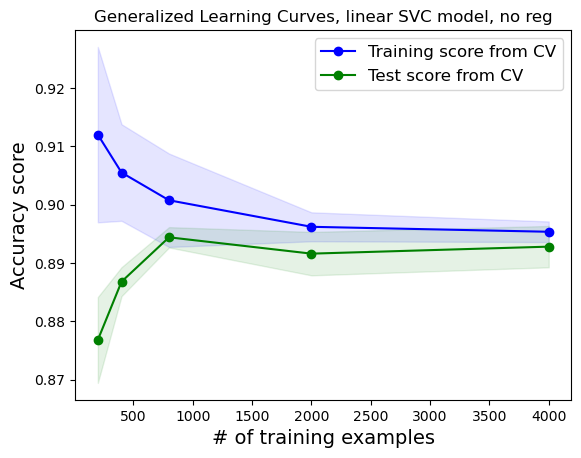

In [38]:
plot_learning_curve(piped_model, 'Generalized Learning Curves, linear SVC model, no reg',
                    features_lim, target, train_sizes = np.array([0.05,0.1,0.2,0.5,1.0]), cv = cv)

In [39]:
# Obtener predicciones usando validación cruzada
ypred_linear = cross_val_predict(
    piped_model,
    features_lim,
    target,
    cv=cv
)

#### Genere una matriz de confusión para esre modelo y evalúe el desempeño del modelo a partir del resultado.

también puede usar la función [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) de `sklearn`

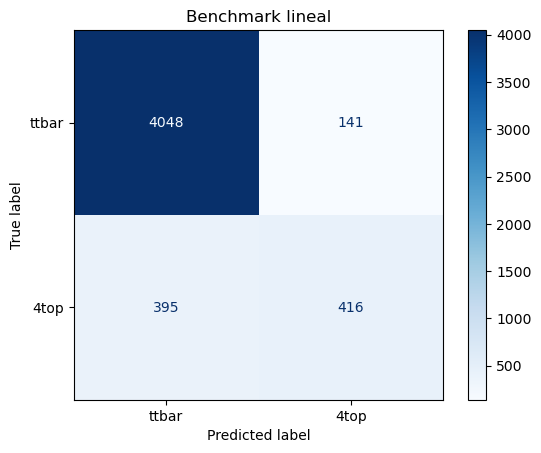

              precision    recall  f1-score   support

       ttbar      0.911     0.966     0.938      4189
        4top      0.747     0.513     0.608       811

    accuracy                          0.893      5000
   macro avg      0.829     0.740     0.773      5000
weighted avg      0.884     0.893     0.884      5000



In [40]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, precision_recall_fscore_support)

def evaluar(y_true, y_pred, nombre, labels=('ttbar', '4top')):
    """Muestra matriz de confusión + reporte y devuelve una fila con las métricas de la clase 4top (=1)."""
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap='Blues', values_format='d')
    plt.title(nombre); plt.show()
    print(classification_report(y_true, y_pred, target_names=labels, digits=3))
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, pos_label=1, average='binary')
    return {'Modelo': nombre,
            'Accuracy': metrics.accuracy_score(y_true, y_pred),
            'Precision 4top': p, 'Recall 4top': r, 'F1 4top': f}

fila_lineal = evaluar(target, ypred_linear, 'Benchmark lineal')

## Conclusiones del benchmark lineal

1. En la curva de aprendizaje, ¿los scores de entrenamiento y validación son altos o bajos?  
   ¿Están separados o son parecidos?

Los scores son altos. Con pocos datos se ve que hay un gap un poco grande pero que converge quedando juntas con el incremento del tamaño de entrenamiento. 

2. ¿La curva sugiere alto bias o alta variance?  
   Justifique usando la relación entre score de entrenamiento y validación.

Train y validación son bastante parecidos, es decir, el modelo no logra ajustar bien ni siquiera los datos de entrenamiento. No hay una brecha grande que indique una alta varianza, además que se ve que si añadimos más datos las curvas no cambiarían.

3. Considerando que usamos \(C=1000\), ¿qué nos dice este resultado sobre la capacidad del modelo lineal?

El modelo está usando toda la flexibilidad que su forma lo permite. Por lo que el límite lo restringe la capacidad del modelo lineal. 

4. En la matriz de confusión, ¿el modelo detecta bien los eventos `4top` o tiende a clasificarlos como `ttbar`?

El modelo detecta mal los 4top, de 811 eventos 4top acierta 416 y manda a 395 a ttbar, en cambio solo 141 en ttbar se clasifican como 4top

5. ¿qué métrica muestra mejor el problema con la clase minoritaria: accuracy, precision, recall o F1-score?

El recall con 0.513, se pierde casi la mitad de la clase minoritaria, mientras que podriamos que decir que tanto accuracy como F1 lo "esconden"  

6. ¿El modelo lineal supera realmente los benchmarks ingenuos, o su buen desempeño se explica principalmente por el desbalance de clases?

Sí supera a los benchmarks ingenuos, pero menos de lo que sugiere la accuracy. El lineal obtiene 0.893 frente a 0.838 del mayoritario y 0.728 del aleatorio, producto del desbalance.

7. ¿Qué evidencia nos indica que necesitamos un modelo más flexible que una frontera lineal?

Bias alto, un recall de 0.51, la gran cantidad de falsos negativos que pueden ser vistos en la matriz de confusión

## Optimización de hiperparámetros

[`GridSearchCV`](https://scikit-learn.org/stable/modules/grid_search.html)selecciona los hiperparámetros que obtienen el mejor desempeño promedio en validación cruzada. Sin embargo, ese score puede ser optimista, porque los mismos folds de validación se usaron para elegir la mejor combinación de hiperparámetros.
Para estimar mejor el desempeño esperado en datos nuevos, se puede usar **validación cruzada anidada**. En este procedimiento, una validación cruzada interna selecciona los hiperparámetros, mientras que una validación cruzada externa evalúa el modelo seleccionado.
La idea central es no usar la misma información para elegir el modelo y para reportar su desempeño final.

La validación cruzada anidada es más rigurosa, pero no siempre vale la pena implementarla. Puede ser muy costosa, porque requiere repetir la búsqueda de hiperparámetros dentro de cada fold externo.En este notebook usaremos `GridSearchCV` para seleccionar hiperparámetros y comparar modelos, pero debemos recordar que el mejor score obtenido puede ser algo optimista. Si el objetivo fuera reportar un resultado final de investigación de manera rigurosa, sería mejor usar un conjunto de prueba independiente o validación cruzada anidada.

In [41]:
#ahora usamos la version general SVC y no la lineal, para cambiar el kernel
piped_model = make_pipeline(StandardScaler(), SVC())
piped_model.get_params() # esto nos muestra los parámetros para el scaler y el clasificador

{'memory': None,
 'steps': [('standardscaler', StandardScaler()), ('svc', SVC())],
 'transform_input': None,
 'verbose': False,
 'standardscaler': StandardScaler(),
 'svc': SVC(),
 'standardscaler__copy': True,
 'standardscaler__with_mean': True,
 'standardscaler__with_std': True,
 'svc__C': 1.0,
 'svc__break_ties': False,
 'svc__cache_size': 200,
 'svc__class_weight': None,
 'svc__coef0': 0.0,
 'svc__decision_function_shape': 'ovr',
 'svc__degree': 3,
 'svc__gamma': 'scale',
 'svc__kernel': 'rbf',
 'svc__max_iter': -1,
 'svc__probability': False,
 'svc__random_state': None,
 'svc__shrinking': True,
 'svc__tol': 0.001,
 'svc__verbose': False}

### Podemos definir un diccionario de valores parámetros para correr la optimización

Note que esto tomará tiempo (~3 min en mi computador)

Una vez que corramos esta celda, el objeto modelo tendra atributos de "best_score_", "best_params_" y "best_estimator_", que nos da acceso al estimador óptimo y "cv_results_" que pueden ser utilizados para visualizar la performance de todos los modelo

In [42]:
%%time
#optimizando SVC, TODAVIA NO ES CV ANIDADA!

#Probamos kernel polinomial y gaussiano, parámetros gamma y degree,
# además del parámetro de regularización
parameters = {'svc__kernel':['poly', 'rbf'], \
              'svc__gamma':[0.00001,'scale', 0.01, 0.1], 'svc__C':[0.1, 1.0, 10.0, 100.0, 1000], \
              'svc__degree': [2, 4, 8]}

# CV para todos los valores de los parámetros del GridSearch
model = GridSearchCV(piped_model, parameters, cv = StratifiedKFold(n_splits=5, shuffle=True), \
                     verbose = 2, n_jobs = 4, return_train_score=True)
model.fit(features_lim,target)

print('Best params, best score:', "{:.4f}".format(model.best_score_), \
      model.best_params_)

Exception ignored in: <function ResourceTracker.__del__ at 0x700fed99e480>
Traceback (most recent call last):
  File "/home/ivanf/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/ivanf/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/ivanf/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7a2f57f8e480>
Traceback (most recent call last):
  File "/home/ivanf/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/ivanf/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/ivanf/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ 

Fitting 5 folds for each of 120 candidates, totalling 600 fits
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=poly; total time=   0.2s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=poly; total time=   0.2s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=poly; total time=   0.3s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=poly; total time=   0.3s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=poly; total time=   0.2s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=rbf; total time=   0.3s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=rbf; total time=   0.4s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=rbf; total time=   0.4s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=rbf; total time=   0.3s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=scale, svc__kernel=poly; total time=   0.3s
[CV] END svc__C=0.1, svc__degre

####  Ahora, visualizamos los modelos en un dataframe, y los rankeamos de acuerdo a los scores de prueba.

Miraremos el promedio y desviación estándar de los test scores, el promedio de los train scores, para evaluar si son distintos  y la significancia del resultado, y fitting time, para elegir el modelo más rápido en vez del mejor modelo, si es que los scores son comparables

In [43]:
scores_lim = pd.DataFrame(model.cv_results_)

scores_lim.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_svc__C', 'param_svc__degree', 'param_svc__gamma',
       'param_svc__kernel', 'params', 'split0_test_score', 'split1_test_score',
       'split2_test_score', 'split3_test_score', 'split4_test_score',
       'mean_test_score', 'std_test_score', 'rank_test_score',
       'split0_train_score', 'split1_train_score', 'split2_train_score',
       'split3_train_score', 'split4_train_score', 'mean_train_score',
       'std_train_score'],
      dtype='object')

In [44]:
scores_lim[['params','mean_test_score','std_test_score','mean_train_score', \
            'mean_fit_time']].sort_values(by = 'mean_test_score', ascending = False)

,params,mean_test_score,std_test_score,mean_train_score,mean_fit_time
37,"{'svc__C': 1.0, 'svc__degree': 4, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8952,0.005115,0.90020,0.235336
45,"{'svc__C': 1.0, 'svc__degree': 8, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8952,0.005115,0.90020,0.247443
29,"{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8952,0.005115,0.90020,0.224012
105,"{'svc__C': 1000, 'svc__degree': 4, 'svc__gamma': 1e-05, 'svc__kernel': 'rbf'}",0.8938,0.005636,0.89495,0.173343
113,"{'svc__C': 1000, 'svc__degree': 8, 'svc__gamma': 1e-05, 'svc__kernel': 'rbf'}",0.8938,0.005636,0.89495,0.196598
97,"{'svc__C': 1000, 'svc__degree': 2, 'svc__gamma': 1e-05, 'svc__kernel': 'rbf'}",0.8938,0.005636,0.89495,0.222399
31,"{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}",0.8934,0.003929,0.93905,0.315205
39,"{'svc__C': 1.0, 'svc__degree': 4, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}",0.8934,0.003929,0.93905,0.317530
47,"{'svc__C': 1.0, 'svc__degree': 8, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}",0.8934,0.003929,0.93905,0.306488
43,"{'svc__C': 1.0, 'svc__degree': 8, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.8926,0.006344,0.92120,0.266602


Observamos que el kernel rbf es preferido constantemente, los valores de $C$ y $\gamma$ no afectan demasiado los scores. GridSearch es insensible a combinaciones de parámetros irrelevantes, por ejemplo, los tres primeros modelos son idénticos porque el grado del kernel polinomial no afecta al kernel rbf.

#### Podemos aislar un solo tipo de kernel

In [45]:
scores_lim[scores_lim['param_svc__kernel'] == 'poly'][['params','mean_test_score','std_test_score',\
                        'mean_train_score','mean_fit_time']].sort_values(by = 'mean_test_score', ascending = False)

,params,mean_test_score,std_test_score,mean_train_score,mean_fit_time
26,"{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8780,0.007348,0.88215,0.302764
74,"{'svc__C': 100.0, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8770,0.007294,0.88790,5.865158
76,"{'svc__C': 100.0, 'svc__degree': 2, 'svc__gamma': 0.01, 'svc__kernel': 'poly'}",0.8766,0.004883,0.88475,0.525784
30,"{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}",0.8766,0.004883,0.88465,0.412488
50,"{'svc__C': 10.0, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8762,0.007359,0.88720,0.762542
78,"{'svc__C': 100.0, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}",0.8760,0.006356,0.88855,16.576751
54,"{'svc__C': 10.0, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}",0.8760,0.005292,0.88755,2.140250
98,"{'svc__C': 1000, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8758,0.006675,0.88890,52.685886
100,"{'svc__C': 1000, 'svc__degree': 2, 'svc__gamma': 0.01, 'svc__kernel': 'poly'}",0.8758,0.005307,0.88760,2.278299
102,"{'svc__C': 1000, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}",0.8756,0.006375,0.88890,148.897431


In [46]:
best_model = model.best_estimator_

ypred_best = cross_val_predict(
    best_model,
    features_lim,
    target,
    cv=cv
)

**Construya la matriz de confusión para el modelo optimizado**

Preguntas:

- ¿Cuál es la accuracy del modelo optimizado? 0.895 
- ¿Cuál es la precision para la clase 4top? 0.748
- ¿Cuál es el recall para la clase 4top? 0.535
- ¿Cuál es el F1-score para la clase 4top? 0.624
- ¿Qué métrica mejoró más respecto al benchmark lineal? El recall de 4top paso de 0.513 a 0.535. Despues sigue F1 con 0.608 a 0.624
- ¿Qué métrica empeoró o cambió muy poco? Nínguna métrica empeoró pero otras como accuracy y precision casi no cambiaron
- ¿La mejora en accuracy refleja una mejora real para la clase 4top? No, al ser una mejora casi nula que termina siendo menor que la std. 
- ¿El modelo optimizado detecta mejor la clase minoritaria que el benchmark lineal? Un poco. Detecta algo más sin perder precision, pero sigue dejando pasar casi la mitad de los 4top.

Complete la tabla de comparación


| Modelo            | Accuracy | Precision `4top` | Recall `4top` | F1-score `4top` | Comentario |
| ----------------- | -------: | ---------------: | ------------: | --------------: | ---------- |
| Benchmark lineal  |  0.893   |0.747	          |0.513          | 0.608           |Alta accuracy, pero pierde ~49% de los `4top`|
| Modelo optimizado |     0.895     | 0.748                  | 0.535               | 0.624                 |Casi igual al lineal en accuracy|

- ¿El modelo optimizado mejora todas las métricas o solo algunas? Mejoran las cuatro pero no de forma equitativa. ya que recall y F1 suben considerablemente si comparamos a accuracy y precision.
- Si una métrica mejora pero otra empeora, ¿cómo decidiría cuál modelo es mejor? Creo que dependeria según el objetivo y contexto del problema, si por ejemplo, 4top fuese resultado extremadamente raro priorizaria recall y F1.
- ¿La mejora justifica usar un modelo más complejo? El SVM y busqueda de hiperparámetros tomó más de 5 minutos y rinde casi igual que el lineal por lo que si consideramos costos de tiempo y computacionales no termina siendo factible por un incremento mínimo en los resultados.




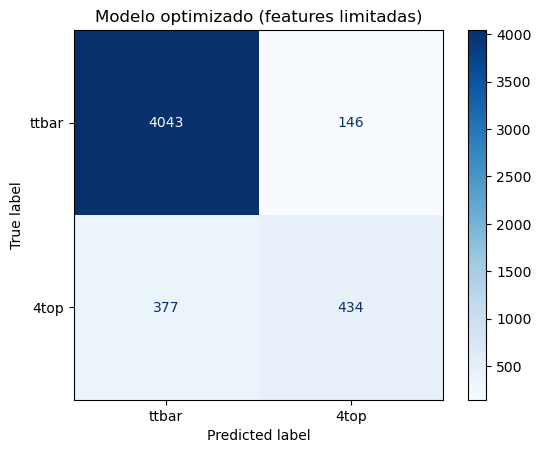

              precision    recall  f1-score   support

       ttbar      0.915     0.965     0.939      4189
        4top      0.748     0.535     0.624       811

    accuracy                          0.895      5000
   macro avg      0.831     0.750     0.782      5000
weighted avg      0.888     0.895     0.888      5000



,Accuracy,Precision 4top,Recall 4top,F1 4top
Modelo,,,,
Benchmark lineal,0.893,0.747,0.513,0.608
Modelo optimizado (features limitadas),0.895,0.748,0.535,0.624


In [47]:
fila_opt = evaluar(target, ypred_best, 'Modelo optimizado (features limitadas)')

tabla = pd.DataFrame([fila_lineal, fila_opt]).set_index('Modelo').round(3)
tabla

#### Diagnóstico final

- ¿Qué modelo elegiría para reportar y por qué? 
El modelo optimizado, ya que es igual o mejor que el Benchmark lineal en las cuatro métricas trabajadas. Su costo extra es solo la busqueda de hiperparámetros que se hace solamente una vez. Si quisiera simpleza, iría por el Benchmark lineal por lo que se comento anteriormente.
- ¿Qué limitación importante todavía tiene el modelo? Sigue perdiendo casi la mitad de los eventos 4top, esto se debe a que las features limitadas no contiene informacion suficiente para separar bien las clases.

## Actividad final: mejorar el modelo

Hasta ahora usamos un conjunto limitado de features para construir y optimizar nuestros modelos. Sin embargo, el desempeño de un modelo no depende solo del algoritmo o de los hiperparámetros: también depende de la información que le entregamos.

En este dataset, cada evento contiene información de varias partículas reconstruidas. Como los eventos `4top` suelen ser más complejos que los eventos `ttbar`, es razonable pensar que usar más información del evento podría ayudar al modelo a distinguir mejor ambas clases.

**Proponga una estrategia para mejorar el modelo explorando nuevas features o usando una representación más completa de los eventos.**

Puede considerar, por ejemplo:

- incluir información de más partículas;
- usar todas las partículas disponibles;
- construir variables derivadas;
- modificar el tratamiento de valores faltantes;
- comparar distintos subconjuntos de features;
- cambiar la métrica usada para optimizar el modelo.

Luego evalúe si su propuesta mejora el desempeño respecto al modelo anterior.

### Preguntas

1. ¿Qué cambio hizo?
4. ¿Mejoró la detección de eventos `4top`?
5. ¿Qué ocurrió con la matriz de confusión?
6. ¿La mejora justifica el aumento de complejidad?
7. ¿Qué aprendió sobre la importancia de las features en este problema?

In [ ]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)

type_cols = [c for c in features.columns if c.startswith('Type_')]
num_cols  = [c for c in features.columns if c not in type_cols]
print(len(type_cols), 'columnas de tipo;', len(num_cols), 'columnas numéricas')
print(pd.unique(features[type_cols].values.ravel()))

13 columnas de tipo; 54 columnas numéricas
['j' 'b' 'm+' nan 'e-' 'e+' 'm-' 'g']


In [49]:
def construir_features(df):
    """Rellena faltantes y agrega variables derivadas. Es una transformación fila a fila (sin leakage)."""
    X = df.copy()
    tipos = X[type_cols]
    X['n_part'] = tipos.notna().sum(axis=1)
    X['n_b']    = (tipos == 'b').sum(axis=1)
    X['n_jets'] = (tipos == 'j').sum(axis=1)
    # leptones/fotones = lo que no es jet ni b-jet (revisar etiquetas impresas arriba)
    X['n_lep']  = X['n_part'] - X['n_b'] - X['n_jets']

    # Cada partícula k tiene (E, pT, eta, phi) = P(4k-3), P(4k-2), P(4k-1), P(4k)
    n_particulas = len(type_cols)
    E_cols  = [f'P{4*k+1}' for k in range(n_particulas)]
    pT_cols = [f'P{4*k+2}' for k in range(n_particulas)]
    X['HT']     = X[pT_cols].fillna(0).sum(axis=1)
    X['E_tot']  = X[E_cols].fillna(0).sum(axis=1)
    X['pT_max'] = X[pT_cols].fillna(0).max(axis=1)
    X['MET_sobre_HT'] = X['MET'] / (X['HT'] + 1)

    X[type_cols] = X[type_cols].fillna('none')
    X[num_cols]  = X[num_cols].fillna(0)
    return X

X_full = construir_features(features)
derivadas = ['n_part', 'n_b', 'n_jets', 'n_lep', 'HT', 'E_tot', 'pT_max', 'MET_sobre_HT']
X_full[derivadas].describe().T

,count,mean,std,min,25%,50%,75%,max
n_part,5000.0,6.245400e+00,2.157709,1.000000,5.000000,6.000000e+00,7.000000e+00,1.300000e+01
n_b,5000.0,1.418200e+00,0.955767,0.000000,1.000000,1.000000e+00,2.000000e+00,6.000000e+00
n_jets,5000.0,4.492400e+00,2.034790,0.000000,3.000000,4.000000e+00,6.000000e+00,1.300000e+01
n_lep,5000.0,3.348000e-01,0.546231,0.000000,0.000000,0.000000e+00,1.000000e+00,3.000000e+00
HT,5000.0,4.922621e+05,326909.987675,35427.500000,283979.875000,3.889238e+05,5.933143e+05,3.796261e+06
E_tot,5000.0,1.353427e+06,895744.029834,63519.300000,665080.625000,1.140735e+06,1.821468e+06,6.534432e+06
pT_max,5000.0,1.550658e+05,114797.259889,30092.600000,90124.250000,1.190490e+05,1.783345e+05,1.276710e+06
MET_sobre_HT,5000.0,1.573112e-01,0.143660,0.000544,0.054958,1.098544e-01,2.127484e-01,1.294533e+00


In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

num_final = num_cols + derivadas
prep = ColumnTransformer([
    ('num', StandardScaler(), num_final),
    ('cat', OneHotEncoder(handle_unknown='ignore'), type_cols),
])

pipe_full = Pipeline([('prep', prep), ('svc', SVC(kernel='rbf'))])

param_grid = {
    'svc__C':            [1.0, 10.0, 100.0],
    'svc__gamma':        ['scale', 0.001, 0.01],
    'svc__class_weight': [None, 'balanced'],
}

# CV interna: elige hiperparámetros optimizando F1 de la clase 4top (=1)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=7)
grid_full = GridSearchCV(pipe_full, param_grid, cv=inner_cv, scoring='f1', n_jobs=-1)

Exception ignored in: <function ResourceTracker.__del__ at 0x70fff978e480>
Traceback (most recent call last):
  File "/home/ivanf/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/ivanf/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/ivanf/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7af7aa58e480>
Traceback (most recent call last):
  File "/home/ivanf/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/ivanf/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/ivanf/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ 

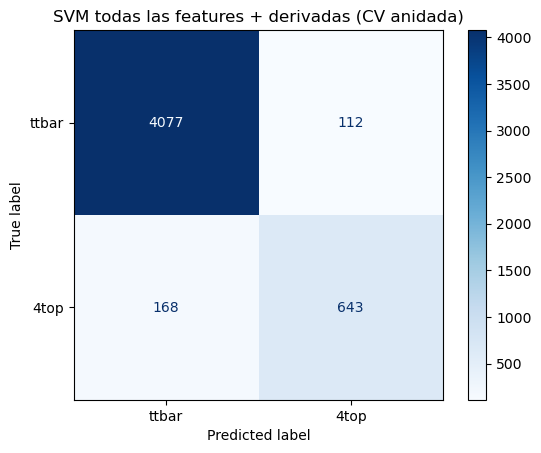

              precision    recall  f1-score   support

       ttbar      0.960     0.973     0.967      4189
        4top      0.852     0.793     0.821       811

    accuracy                          0.944      5000
   macro avg      0.906     0.883     0.894      5000
weighted avg      0.943     0.944     0.943      5000

CPU times: user 4.19 s, sys: 495 ms, total: 4.68 s
Wall time: 31.2 s


In [51]:
%%time
# CV externa: estima el desempeño del procedimiento completo (incluida la búsqueda de hiperparámetros)
ypred_full = cross_val_predict(grid_full, X_full, target, cv=outer_cv, n_jobs=1)
fila_full = evaluar(target, ypred_full, 'SVM todas las features + derivadas (CV anidada)')

In [52]:
# Hiperparámetros elegidos usando todos los datos (solo informativo)
grid_full.fit(X_full, target)
print('Mejor F1 (CV interna):', round(grid_full.best_score_, 3), grid_full.best_params_)

# Comparación final de los tres modelos
tabla_final = pd.DataFrame([fila_lineal, fila_opt, fila_full]).set_index('Modelo').round(3)
tabla_final

Mejor F1 (CV interna): 0.824 {'svc__C': 10.0, 'svc__class_weight': None, 'svc__gamma': 0.001}


,Accuracy,Precision 4top,Recall 4top,F1 4top
Modelo,,,,
Benchmark lineal,0.893,0.747,0.513,0.608
Modelo optimizado (features limitadas),0.895,0.748,0.535,0.624
SVM todas las features + derivadas (CV anidada),0.944,0.852,0.793,0.821


In [54]:
# Importancia de las features: ablation con el mismo pipeline e hiperparámetros
def f1_cv(cols_num, cols_cat, nombre):
    transformers = [('num', StandardScaler(), cols_num)]
    if cols_cat:
        transformers.append(('cat', OneHotEncoder(handle_unknown='ignore'), cols_cat))
    p = Pipeline([
        ('prep', ColumnTransformer(transformers)),
        ('svc', SVC(kernel='rbf', **{k.split('__')[1]: v for k, v in grid_full.best_params_.items()}))])
    r = cross_validate(p, X_full, target, cv=outer_cv, scoring=['f1', 'recall'], n_jobs=-1)
    return {'Conjunto': nombre, 'F1 4top': r['test_f1'].mean(), 'Recall 4top': r['test_recall'].mean()}

limitadas = ['MET', 'METphi'] + [f'P{i}' for i in range(1, 17)]
ablation = pd.DataFrame([
    f1_cv(limitadas, [], 'Features limitadas (original)'),
    f1_cv(num_cols, [], 'Todas las numéricas'),
    f1_cv(num_cols, type_cols, '+ tipos de partícula'),
    f1_cv(num_final, type_cols, '+ variables derivadas (propuesta completa)'),
    f1_cv(['MET'] + derivadas, [], 'Solo MET + derivadas'),
]).set_index('Conjunto').round(3)
ablation

,F1 4top,Recall 4top
Conjunto,,
Features limitadas (original),0.613,0.523
Todas las numéricas,0.784,0.748
+ tipos de partícula,0.817,0.778
+ variables derivadas (propuesta completa),0.822,0.790
Solo MET + derivadas,0.831,0.801


Exception ignored in: <function ResourceTracker.__del__ at 0x7802e0396480>
Traceback (most recent call last):
  File "/home/ivanf/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/ivanf/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/ivanf/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f40dbd86480>
Traceback (most recent call last):
  File "/home/ivanf/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/ivanf/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/ivanf/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ 

| Modelo | Accuracy | Precision `4top` | Recall `4top` | F1 `4top` |
 |---|---:|---:|---:|---:|
 | Benchmark lineal (features limitadas) | 0.893 | 0.747 | 0.513 | 0.608 |
 | SVM todas las features + derivadas (CV anidada) | **0.944** | **0.852** | **0.793** | **0.821** |


### Preguntas

1. ¿Qué cambio hizo?

Usé todas las columnas, las 13 partículas con sus tipos, en vez de solo las 4 primeras partículas sin su tipo. Agregé otro tipo de variables, por ejemplo, número de partículas, de b jets, de jets y de leptones, suma de pT, energía total, pT máximo y Energía faltante relativa a la actividad total. Usé class_weight y también optimicé F1. Cross validation anidada para no obtener resultados no deseados. 

4. ¿Mejoró la detección de eventos `4top`?

Sí, mejoro bastante. El recall subio a 0.793, presicion 0.852 y el F1 a 0.821 

5. ¿Qué ocurrió con la matriz de confusión?

Los True positives pasaron de 416 a 643, los false negatives bajaron considerablemente a 168, y false positives también bajaron a 112. 

6. ¿La mejora justifica el aumento de complejidad?

Sí. La CV anidada completa tardó casi un minuot, el modelo sigue siendo SVM y la mejora es bastante grande. F1 de 4top sube al igual que el recall. Bajan False negatives y false positives. 

7. ¿Qué aprendió sobre la importancia de las features en este problema?

La información termina siendo más valiosa que el algoritmo. Al pasar de un modelo lineal a un RBF con las mismas features no cambia practicamente nada, pero darle al modelo más partículas, sus tipos y otras variables sube la accuracy bastante. Tiene sentido, porque un evento 4top tiene más objetos y mas energía que ttbar y esas varibles resumen la diferencia.  
